# INFO-H512 Project

## Project Overview 

The goal of the project is to study in depth one state-of-the-art AI method presented in the seminar. This project focuses on Explainable AI, a topic at the intersection of Mr Sacharidis's seminar on "Counterfactuals for Explainability and Fairness" and Mr Nematov's seminar on "Attribution in Black-Box ML models". 

More specifically, it explores influence-estimation methods and their ability to draw useful insights regarding the model interpretability. 

## Imports

In [11]:
import numpy as np
from sklearn.model_selection import (train_test_split, StratifiedKFold, RandomizedSearchCV)
import lightgbm
from lightgbm import LGBMClassifier
from tree_influence.explainers import BoostIn
import pandas as pd 
import sklearn 
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    fbeta_score,
    make_scorer,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score,
    roc_curve
)
from matplotlib import pyplot as plt

import warnings
warnings.filterwarnings("ignore", category=UserWarning,
                        module="sklearn")
import shap

/opt/anaconda3/envs/INFOH512/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Preparation
The German credit dataset was chosen for this analysis (find the dataset [here](https://www.kaggle.com/datasets/kabure/german-credit-data-with-risk)). In this dataset, each entry represents a person who takes a credit by a bank. Each person is classified as good or bad credit risks according to the set of attributes.

### 1.1 Data Loading and Descriptive Analysis

In [2]:
# load german credit data 
data = pd.read_csv('german_credit_data.csv', index_col=0)

# check data type 
print("======= Data types =======")
print(data.dtypes)

# brief summary of integers 
print("\n======= Data summary =======")
print(data.describe())

# brief summary for categorical variables 
print("\n======= Categorical value counts =======")
cat_cols = data.select_dtypes(include='object').columns
for col in cat_cols: 
    counts = data[col].value_counts(dropna=False).to_frame(name='count')
    counts['%'] = (counts['count']/len(data)*100).round(1)
    print(f"\n--- {col} ---")
    print(counts)

# count NaN 
print("\n======= NaN count =======")
nan_count = data.isna().sum()
print(nan_count)

======= Data types =======
Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
Risk                object
dtype: object

======= Data summary =======
               Age          Job  Credit amount     Duration
count  1000.000000  1000.000000    1000.000000  1000.000000
mean     35.546000     1.904000    3271.258000    20.903000
std      11.375469     0.653614    2822.736876    12.058814
min      19.000000     0.000000     250.000000     4.000000
25%      27.000000     2.000000    1365.500000    12.000000
50%      33.000000     2.000000    2319.500000    18.000000
75%      42.000000     2.000000    3972.250000    24.000000
max      75.000000     3.000000   18424.000000    72.000000

======= Categorical value counts =======

--- Sex ---
        count     %
Sex                
male      690  69.0
fema

Regarding data types, it seems that categorical variables have the `object` type. This should be changed to the `category` type so that LightGBM can handle them. Categorical variables won't be one-hot-encoded as LightGBM can handle them.

The brieve descriptive analysis on numerical data reveals that there is not a strong presence of outliers as the mean is close to the median. 

The brieve descriptive analysis on categorical variables reveals that $30\%$ of the dataset is flagged as bad credit risk. the target variable `Risk`should be mapped to binary values: $0$ for `good`and $1$ for `bad`. 

The NaN count reveals that `Saving accounts` and `Checking account` contains NaN values. However, as LightGBM handles NaN values natively (see [LightGBM documentation](https://lightgbm.readthedocs.io/en/v3.3.2/Advanced-Topics.html)), no imputation will be performed in data preprocessing steps. 

### 1.2 Data Preprocessing 

In [3]:
# categorical columns have type 'object', should transform in category pandas dtype for LightGBM
cat_cols = ["Sex", "Housing", "Saving accounts", "Checking account", "Purpose"]
for c in cat_cols: 
    data[c] = data[c].astype('category')
    
# binary encoding for target value 
data["Risk"] = data["Risk"].replace({'good': 0, 'bad': 1})

# prepare target and features datasets 
y = data["Risk"]
X = data.drop(columns="Risk").copy()

# BoostIn will require numpy afterwards 
for c in cat_cols: 
    X[c] = X[c].cat.codes 
    X[c] = X[c].astype('float').replace(-1, np.nan)

cat_idx = [X.columns.get_loc(c) for c in cat_cols]

/var/folders/l5/1_f10tdn2tq4r52l8yvcrf640000gn/T/ipykernel_14335/1569512468.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["Risk"] = data["Risk"].replace({'good': 0, 'bad': 1})


## 2. Model 

### 2.1 Model Training and Evaluation with Baseline Hyperparameters

#### A. Functions

In [4]:
def compute_model_metrics(y_true, y_pred, y_proba):
    scores = {k: [] for k in ["accuracy", "recall", "precision", "f1", "f2", "roc_auc", "pr_auc"]}
    scores["accuracy"].append(accuracy_score(y_true, y_pred))
    scores["recall"].append(recall_score(y_true, y_pred))
    scores["precision"].append(precision_score(y_true, y_pred))
    scores["f1"].append(f1_score(y_true, y_pred))
    scores["f2"].append(fbeta_score(y_true, y_pred, beta=2))
    scores["roc_auc"].append(roc_auc_score(y_true, y_proba))
    scores["pr_auc"].append(average_precision_score(y_true, y_proba))
    return scores

#### B. Pipeline

In [5]:
# Train and evaluate model in CV (k=5)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = {k: [] for k in ["accuracy", "recall", "precision", "f1", "f2", "roc_auc", "pr_auc"]}

for train_idx, val_idx in cv.split(X,y): 
    X_train, X_test = X.iloc[train_idx].to_numpy(), X.iloc[val_idx].to_numpy()
    y_train, y_test = y.iloc[train_idx].to_numpy(), y.iloc[val_idx].to_numpy()

    model = LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced').fit(X_train, y_train, categorical_feature=cat_idx)
    y_hat = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1] # predicted proba of belonging to bad class -> take second column

    fold_scores = compute_model_metrics(y_test, y_hat, y_proba)
    
    for name, val in fold_scores.items():
        scores[name].append(val[0] if isinstance(val, list) else val)

results=pd.DataFrame(scores)
summary = results.agg(['mean', 'std']).T            
summary.columns = ['Mean', 'Std']
summary = summary.round(3)
print("======= Performance in CV (k=5) =======")
print(summary)

======= Performance in CV (k=5) =======
            Mean    Std
accuracy   0.714  0.023
recall     0.537  0.030
precision  0.524  0.037
f1         0.530  0.032
f2         0.534  0.030
roc_auc    0.739  0.020
pr_auc     0.577  0.021


### 2.2 Finetuning 
Regarding hyperparameters finetuning, the focus was on the ones recommanded by [LightGBM documentation](https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html): `num_leaves` (to control complexity), `max_depth` (also for complexity, must be careful that `num_leaves` <= `max_depth`) and `min_child_samples` (to control for overfitting). 

Hyperparameters are finetuned to optimise the F2-score as the model is dealing with a credit-risk detection problematic. In such settings, missclassifying a bad debtor as a good one costs more to an institution, meaning that recall, the true positive rate, is an important metric. F2-score is defined as the harmonic mean between precision and recall, giving twice as much importance to recall as to precision and is therefore a good candidate for optimisation. 

In [6]:
hyper_param_grid = {
    "num_leaves": [7,15,31,63], # LightGBM doc -> num_leaves <= 2^max_depth
    "max_depth": [3,4,5,6,-1], 
    "min_child_samples": [5,10,20,50,100],
}

In [7]:
# define model to pass through RandomizedGridSearch
model_for_grid = LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced')

# define parameters of CV 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# randomized grid search of hyperparameters 
randomized_grid_search = RandomizedSearchCV(
    model_for_grid, 
    param_distributions=hyper_param_grid,
    scoring=make_scorer(fbeta_score, beta=2),
    cv=cv, 
    n_jobs=1, 
    random_state=42, 
    verbose=0, 
    return_train_score=True)

randomized_grid_search.fit(X.to_numpy(), y.to_numpy(), categorical_feature=cat_idx)

print("Best params :", randomized_grid_search.best_params_)
print("Best F2     :", round(randomized_grid_search.best_score_, 3))

Best params : {'num_leaves': 63, 'min_child_samples': 100, 'max_depth': 4}
Best F2     : 0.628


### 2.3 Model Evaluation with Finetuned Hyperparameters
Best hyperparameters are passed through the model. The model is fit on the whole training set and evaluated on the hold-out set. ROC and PR curves are plotted. 

#### A. Functions 

In [8]:
def plot_curves(y_true, y_pred):
        roc_auc = roc_auc_score(y_true, y_pred)
        pr_auc = average_precision_score(y_true, y_pred)

        # ROC curve 
        fpr, tpr, _ = roc_curve(y_true, y_pred)
        plt.figure(figsize=(5, 4))
        plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
        plt.plot([0, 1], [0, 1], "k--", alpha=0.6)
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # PR curve 
        precision, recall, threshold = precision_recall_curve(y_true, y_pred)
        plt.figure(figsize=(5, 4))
        plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"Precision-Recall Curve")
        plt.legend()
        plt.tight_layout()
        plt.show()

#### B. Pipeline

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

model = LGBMClassifier(random_state=42, verbose=-1, class_weight='balanced', num_leaves=63, max_depth=4, min_child_samples=100).fit(X_train, y_train)
y_hat_test = model.predict(X_test)
y_proba_test = model.predict_proba(X_test)[:,1]
y_hat_train = model.predict(X_train)
y_proba_train = model.predict_proba(X_train)[:,1]

print("======= Performance on Training Set =======")
scores_train = compute_model_metrics(y_train, y_hat_train, y_proba_train)
results_train = pd.DataFrame(scores_train)
print(results_train)

print("\n======= Performance on Validation Set =======")
scores_val = compute_model_metrics(y_test, y_hat_test, y_proba_test)
results_val = pd.DataFrame(scores_val)
print(results_val)

======= Performance on Training Set =======
   accuracy    recall  precision        f1        f2   roc_auc    pr_auc
0    0.7625  0.779167    0.57716  0.663121  0.728193  0.847667  0.708923

======= Performance on Validation Set =======
   accuracy    recall  precision        f1        f2   roc_auc    pr_auc
0     0.705  0.783333   0.505376  0.614379  0.705706  0.832857  0.725909


Performances on training and validation set shows that the model does not overfit. 

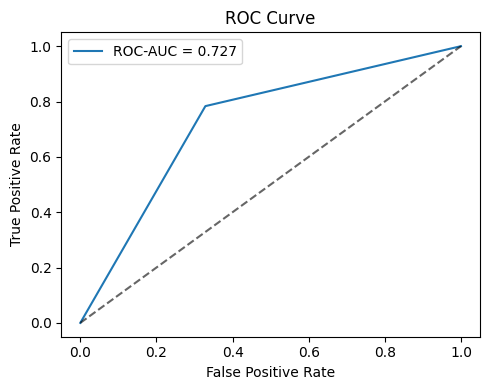

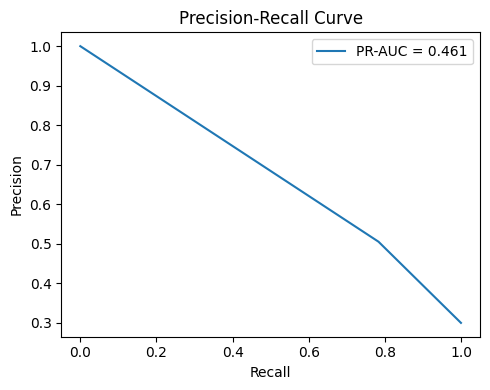

In [10]:
plot_curves(y_test, y_hat_test)

## 3. SHapley Additive Explanation (SHAP)
For this part, the [API of Lundberg and Lee (2017)](https://shap.readthedocs.io/en/latest/index.html) is used. 

As our project focuses on local interpretation, waterfall plot will mainly be used for the feature attribution section. Waterfall plots are specifically designed to display explanations for individual predictions. More precisely, these plots decompose a single prediction into the contribution of each feature relative to the model’s baseline prediction (Lundberg and Lee, 2017).

### 3.1 Computing SHAP values

After the model training, one should compute SHAP values for the whole validation set as the goal is to get local explanation for a missclassified test point. 

In [ ]:
# computing SHAP values, this results in an array of size (200,9) containing SHAP contribution of each feature for each observation. 

explainer = shap.Explainer(model, X_test)
shap_values_validation = explainer(X_test)

### 3.2 Selecting Missclassified Points for Local Interpretation 

In [31]:
fn_mask = (y_test == 1) & (y_hat_test == 0)
tp_mask = (y_test == 1)
fn_positions = np.where(fn_mask)[0]
tp_positions = np.where(tp_mask)[0]

print(f"The number of missclassified risky creditors is {len(fn_positions)}, representing {(len(fn_positions)/len(X_test))*100:.2f} % of the validation dataset and {(len(fn_positions)/len(tp_positions))*100:.2f} % of the risky creditors.")

The number of missclassified risky creditors is 13, representing 6.50 % of the validation dataset and 21.67 % of the risky creditors.


In [25]:
X_test.iloc[fn_positions]

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
129,29,0.0,2,1.0,0.0,0.0,3499,12,1.0
558,27,1.0,2,1.0,0.0,0.0,3552,24,4.0
470,22,1.0,2,2.0,1.0,1.0,3092,24,5.0
864,25,1.0,1,2.0,0.0,NaN,2210,10,4.0
174,26,1.0,2,1.0,0.0,0.0,3414,21,3.0
521,24,0.0,2,1.0,0.0,0.0,3190,18,5.0
331,30,0.0,2,1.0,1.0,NaN,1864,18,3.0
190,54,1.0,3,1.0,3.0,NaN,4591,24,0.0
878,27,1.0,3,0.0,0.0,0.0,1422,9,1.0
563,37,1.0,2,0.0,NaN,1.0,12389,36,1.0


### 3.3 Ploting Waterfall Plots for Missclassified Points

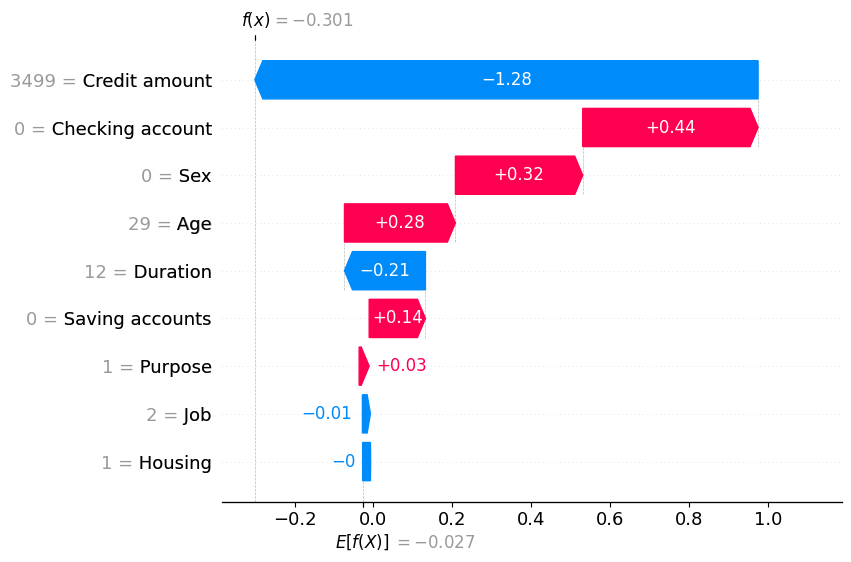

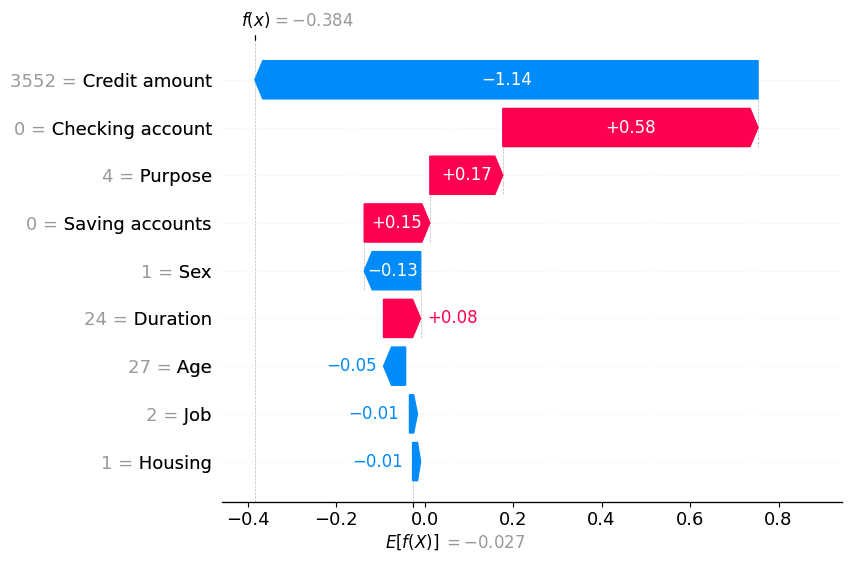

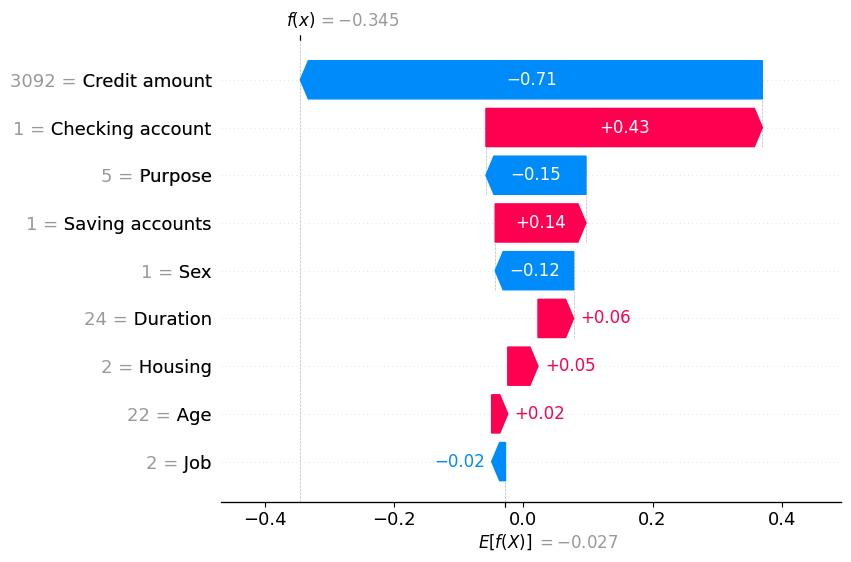

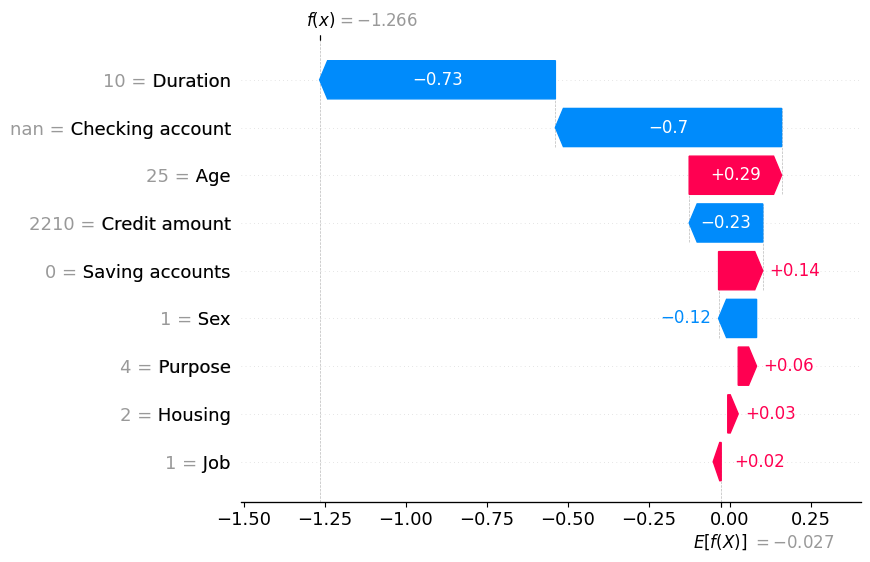

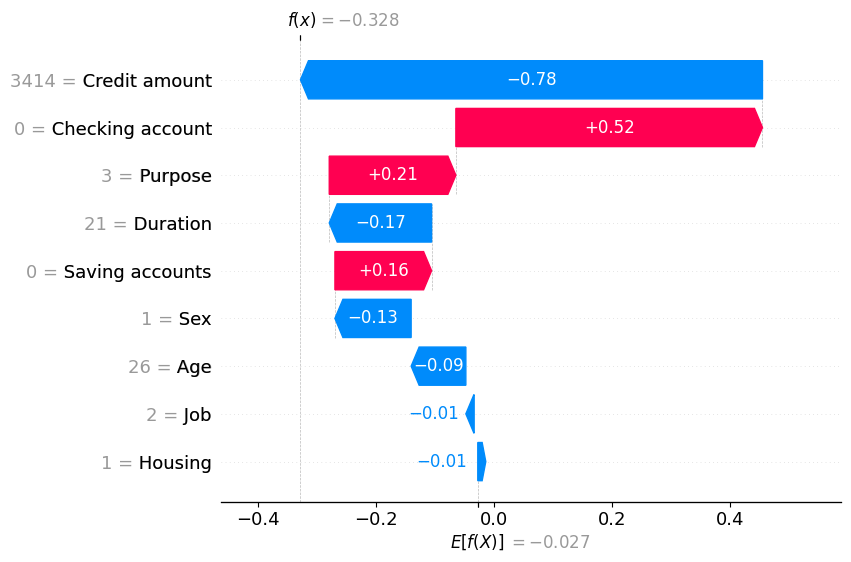

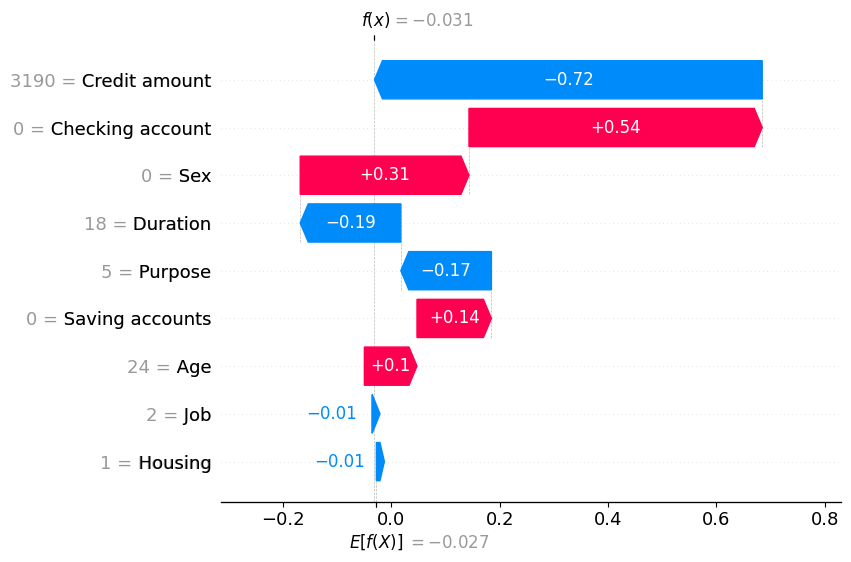

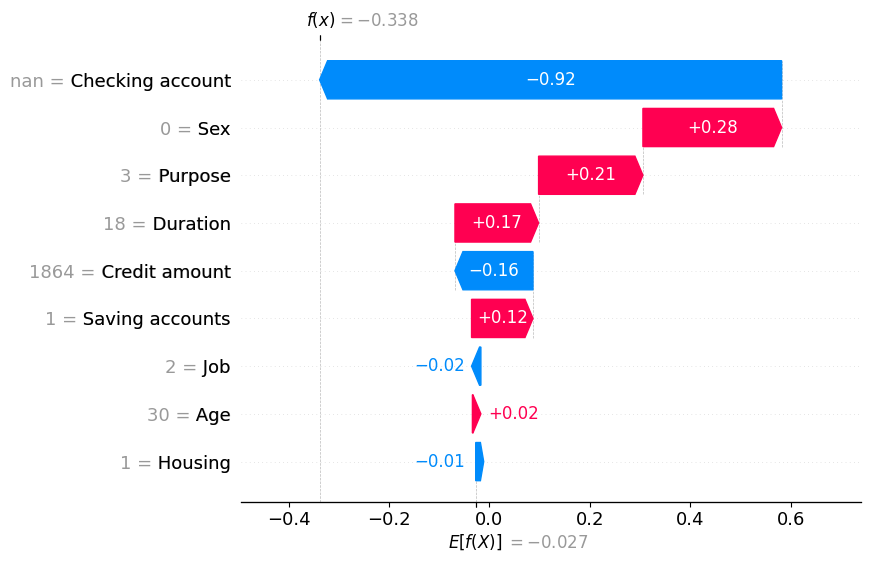

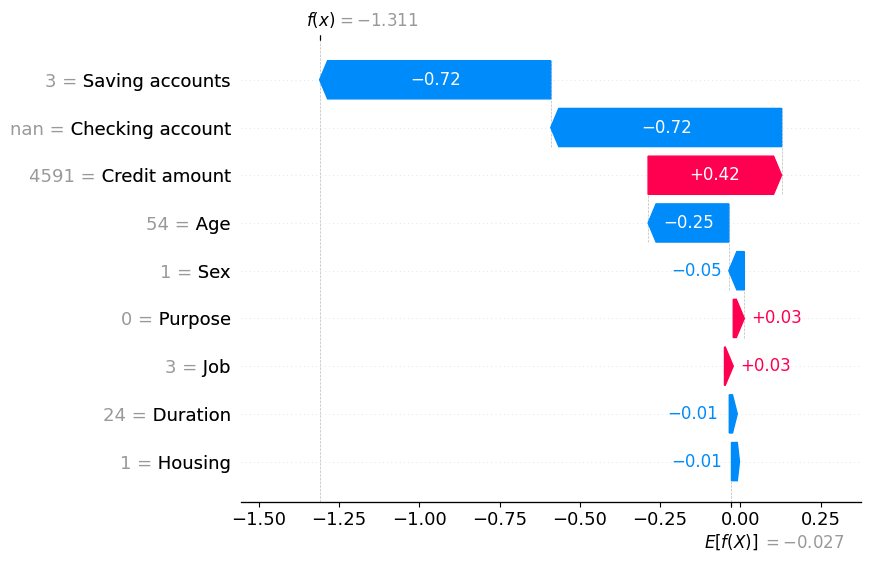

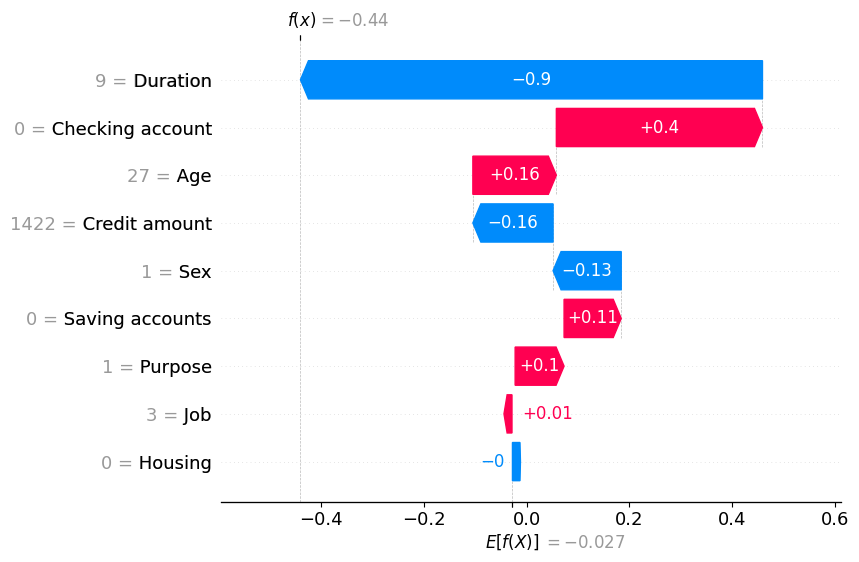

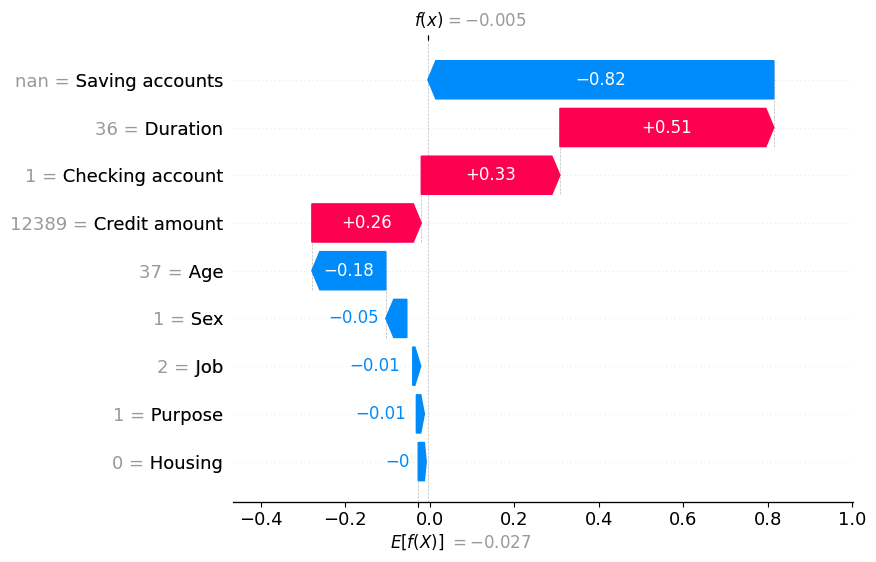

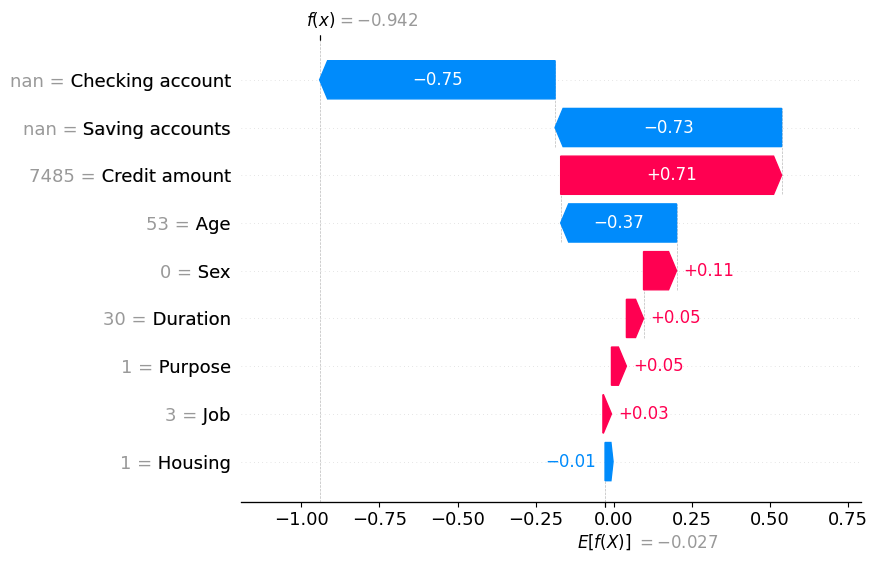

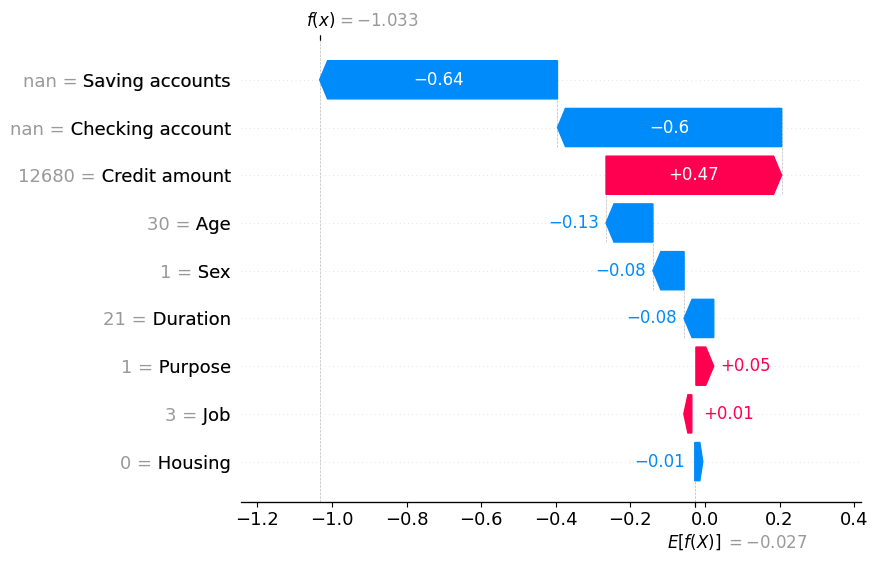

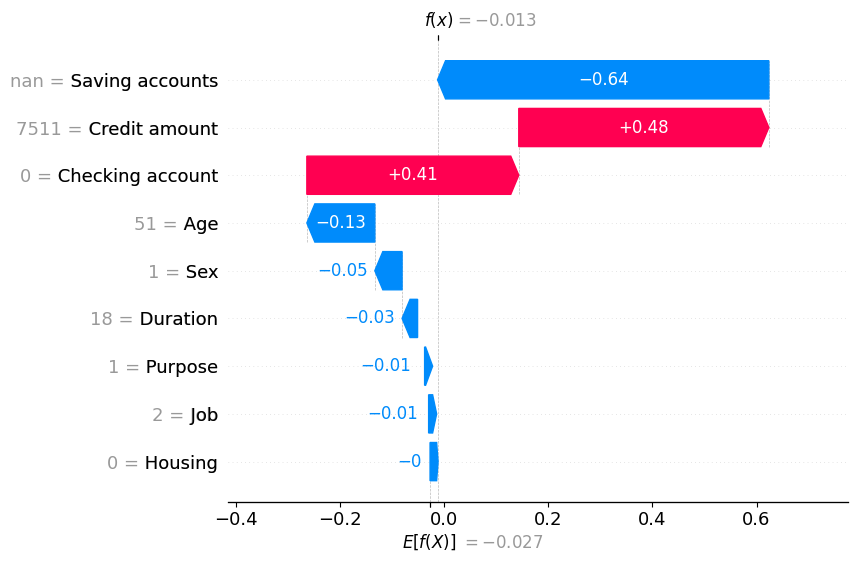

In [26]:
# Here, done for 5 of them 

for i in fn_positions: 
    shap.plots.waterfall(shap_values_validation[i])

## Visualisation of top 5 most influential points for a given test point

In [ ]:
# fit influence estimator
explainer = BoostIn().fit(model, X_train_np, y_train_np)

# estimate training influences on each test instance
influence = explainer.get_local_influence(X_test_np, y_test_np)  # shape=(no. train, no. test)

# extract influence values for the first test instance
values = influence[:, 0]  # retrieve first column, meaning influence of each training example on first test

# sort training examples from:
# - most positively influential (decreases loss of the test instance the most), to
# - most negatively influential (increases loss of the test instance the most)
training_idxs = np.argsort(values)[::-1]

In [14]:
print("Tested client profile :")
print(X_test.iloc[0])
print("True label:", y_test.iloc[0])
print("Model prediction:", model.predict(X_test_np[[0]])[0])
print("Predicted probability:", model.predict_proba(X_test_np[[0]])[0,1])

Tested client profile :
Age                               66
Job                                0
Credit amount                   1480
Duration                          12
Sex_male                        True
Housing_own                    False
Housing_rent                   False
Saving accounts_moderate       False
Saving accounts_quite rich      True
Saving accounts_rich           False
Checking account_moderate      False
Checking account_rich           True
Purpose_car                     True
Purpose_domestic appliances    False
Purpose_education              False
Purpose_furniture/equipment    False
Purpose_radio/TV               False
Purpose_repairs                False
Purpose_vacation/others        False
Name: 774, dtype: object
True label: 0
Model prediction: 0
Predicted probability: 0.0727594706516854


/opt/anaconda3/envs/INFOH512/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/INFOH512/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [15]:
print("Influence matrix :", influence.shape)
print("Top 5 proponent examples:", training_idxs[:5])
print("Top 5 oponont examples:", training_idxs[-5:])

# Et regarder les vrais exemples concernés :
data.iloc[training_idxs[:5]]

Influence matrix : (800, 200)
Top 5 proponent examples: [ 93 397 467 206 460]
Top 5 oponont examples: [ 56 340  69 618 313]


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
93,20,male,2,rent,NaN,rich,3617,24,furniture/equipment,0
397,46,male,2,own,little,little,2348,36,furniture/equipment,0
467,32,male,2,own,NaN,NaN,7238,48,radio/TV,0
206,43,male,2,own,little,NaN,1935,12,furniture/equipment,0
460,37,male,2,own,little,little,3620,36,furniture/equipment,0


/var/folders/l5/1_f10tdn2tq4r52l8yvcrf640000gn/T/ipykernel_66213/1850781047.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["Risk"] = data["Risk"].replace({"good": 0, "bad": 1})
/opt/anaconda3/envs/INFOH512/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/INFOH512/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/INFOH512/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was

N = 750   Pearson r = +0.390   (p = 1.34e-28)


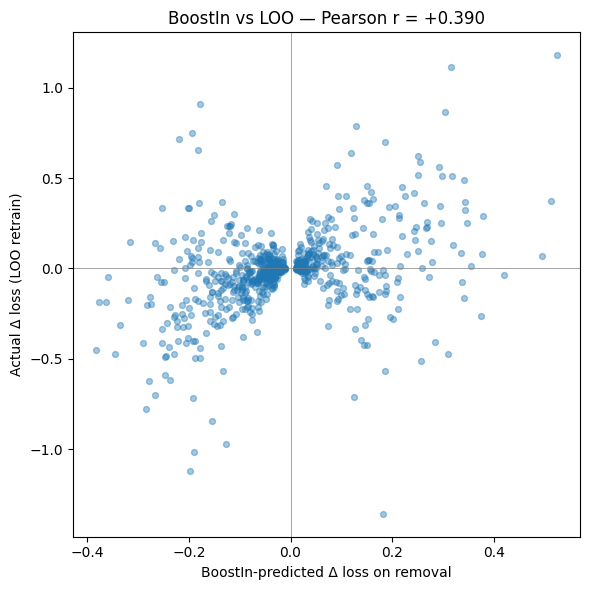

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from tree_influence.explainers import BoostIn

# --- 1. Données ---
data = pd.read_csv("german_credit_data.csv", index_col=0, na_values=["NA"])
data["Risk"] = data["Risk"].replace({"good": 0, "bad": 1})
y = data["Risk"]
X = pd.get_dummies(data.drop(columns="Risk"), drop_first=True)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)
X_tr_np, X_te_np = X_tr.to_numpy(), X_te.to_numpy()
y_tr_np, y_te_np = y_tr.to_numpy(), y_te.to_numpy()

# --- 2. Modèle de base + losses de référence ---
MODEL_PARAMS = dict(n_estimators=100, random_state=1,
                    deterministic=True, verbose=-1)

def per_sample_logloss(model, X, y):
    p = model.predict_proba(X)
    return -np.log(np.clip(p[np.arange(len(y)), y], 1e-12, 1.0))

base_model = LGBMClassifier(**MODEL_PARAMS).fit(X_tr_np, y_tr_np)
base_losses = per_sample_logloss(base_model, X_te_np, y_te_np)

# --- 3. Choix des 50 tests + BoostIn ---
N_TEST, K = 50, 15
rng = np.random.default_rng(0)
test_idx = rng.choice(len(X_te_np), size=N_TEST, replace=False)

explainer = BoostIn().fit(base_model, X_tr_np, y_tr_np)
influence = explainer.get_local_influence(X_te_np[test_idx], y_te_np[test_idx])
# shape : (n_train, N_TEST)

# --- 4. LOO retraining sur les top-k de chaque test ---
predicted, actual = [], []

for t, te_i in enumerate(test_idx):
    col = influence[:, t]
    topk = np.argsort(np.abs(col))[-K:]              # |influence| → on garde proponents ET opponents

    for tr_i in topk:
        mask = np.ones(len(X_tr_np), dtype=bool)
        mask[tr_i] = False
        m_loo = LGBMClassifier(**MODEL_PARAMS).fit(X_tr_np[mask], y_tr_np[mask])
        loo_loss = per_sample_logloss(m_loo, X_te_np[[te_i]], y_te_np[[te_i]])[0]

        predicted.append(col[tr_i])                  # signe à valider, voir ci-dessous
        actual.append(loo_loss - base_losses[te_i])

predicted = np.array(predicted)
actual = np.array(actual)

# --- 5. Pearson + plot ---
r, p = pearsonr(predicted, actual)
print(f"N = {len(predicted)}   Pearson r = {r:+.3f}   (p = {p:.2e})")

plt.figure(figsize=(6, 6))
plt.scatter(predicted, actual, alpha=0.4, s=18)
plt.axhline(0, color="gray", lw=0.5); plt.axvline(0, color="gray", lw=0.5)
plt.xlabel("BoostIn-predicted Δ loss on removal")
plt.ylabel("Actual Δ loss (LOO retrain)")
plt.title(f"BoostIn vs LOO — Pearson r = {r:+.3f}")
plt.tight_layout(); plt.show()
